# Measuring Performance in Regression Models

## Initializations

In [21]:
# Required packages
import pandas as pd       # For data handling
import numpy as np        # For numerical operations (optional but useful)
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns     # For nicer statistical plots
import scienceplots
from scipy.stats import skew
from scipy.stats import ttest_rel
from scipy.stats import binomtest
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.preprocessing import PowerTransformer # For transformations 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA # For Principal Component Analysis
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GroupShuffleSplit
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV, KFold, RepeatedStratifiedKFold, StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate


import sys
import os

# Absolute path to the repo root
repo_root = os.path.abspath(os.path.join(os.getcwd(), "../"))

if repo_root not in sys.path:
    sys.path.append(repo_root)

from utils import check_transform_suitability, selective_transform, near_zero_var, find_correlation, plot_corr

# Set the plotting style
sns.set_theme(style="darkgrid")  # Set theme for seaborn plots

# Load data required for the analysis in this notebook
two_cd = pd.read_parquet("../../data/twoClassData.parquet")
german_credit = pd.read_parquet("../../data/GermanCredit.parquet")
chem_man_pro = pd.read_parquet("../../data/ChemicalManufacturingProcess.parquet")
oil_df = pd.read_parquet("../../data/oil_data.parquet")

## Computing

In [26]:
observed = np.array([
    0.22, 0.83, -0.12, 0.89, -0.23, -1.30, -0.15, -1.40,
    0.62, 0.99, -0.18, 0.32, 0.34, -0.30, 0.04, -0.87,
    0.55, -1.30, -1.15, 0.20
])

predicted = np.array([
    0.24, 0.78, -0.66, 0.53, 0.70, -0.75, -0.41, -0.43,
    0.49, 0.79, -1.19, 0.06, 0.75, -0.07, 0.43, -0.42,
    -0.25, -0.64, -1.26, -0.07
])

residual_values = observed - predicted
print("Median: ", np.median(residual_values))
pd.Series(residual_values).describe()

Median:  0.08000000000000002


count    20.000000
mean     -0.031000
std       0.536145
min      -0.970000
25%      -0.420000
50%       0.080000
75%       0.262500
max       1.010000
dtype: float64

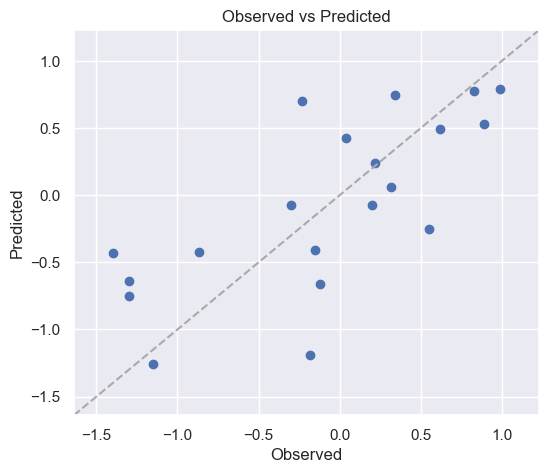

In [ ]:
ax_min = np.concatenate((observed, predicted)).min()
ax_max = np.concatenate((observed, predicted)).max()
axis_range = [ax_min - 0.1*(ax_max - ax_min), ax_max + 0.1*(ax_max - ax_min)]

# Observed vs Predicted plot
plt.figure(figsize=(6, 5))
plt.scatter(observed, predicted)
plt.xlim(axis_range)
plt.ylim(axis_range)

# Diagonal line
plt.axline((0, 0), slope=1, color="darkgrey", linestyle="--")


plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted")
plt.show()

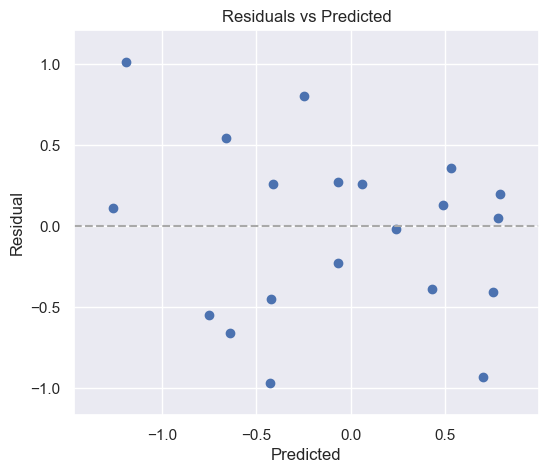

In [ ]:
x_min, x_max = np.min(predicted),  np.max(predicted)
y_min, y_max = np.min(residual_values),  np.max(residual_values)
x_range = [x_min - 0.1*(x_max - x_min), x_max + 0.1*(x_max - x_min)]
y_range = [y_min - 0.1*(y_max - y_min), y_max + 0.1*(y_max - y_min)]

plt.figure(figsize=(6, 5))
plt.scatter(predicted, residual_values)
plt.xlim(x_range)
plt.ylim(y_range)

# Horizontal zero line
plt.axhline(0, color='darkgrey', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()

In [ ]:
# R^2
r2 = r2_score(observed, predicted)

# RMSE
rmse = root_mean_squared_error(observed, predicted)


print("R²:", r2) # This does not align with the value in the book. However, data appears to be correct.
print("RMSE:", rmse) # Correct value.

R²: 0.4966016385612989
RMSE: 0.523488299773739
